# Should you hold 100% stocks your WHOLE life? 🌍
### The famous 2023 "death of the 60/40 and the target-date fund" paper, raced on 152 years of data

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Worst_cohorts%3F: Busted](https://img.shields.io/badge/Worst_cohorts%3F-Busted-8b949e?style=flat-square)

In 2023, three finance professors (Anarkulova, Cederburg & O'Doherty) published a paper that made headlines everywhere: *forget bonds entirely*. Simulating lifetimes on returns from 38 developed countries, they found that saving into **100% stocks — half your own country, half international — and never touching a bond**, beats the balanced 60/40 portfolio and the target-date funds your 401(k) defaults into. Not just on final wealth — on the **probability of dying broke**, too.

We rebuild that horse race on the longest public tape there is: every possible 70-year lifecycle (save 40 years, retire 30) on US data since 1871, with an honestly-labeled international proxy.

> 📓 Want the *t*-stats, the bootstraps and the sensitivity grid? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**. Numbers quoted here are the frozen headline run ([docs/results.md](../docs/results.md)); every chart is drawn by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY, BLUE = "#c0392b", "#dab617", "#2ea44f", "#8b949e", "#2b6cb0"

from cederburg_100_equities import data, strategy as st

HAVE_REAL = ((os.path.exists(data.SHILLER_PATH)
              or any(os.path.exists(p) for p in data._FALLBACKS))
             and os.path.exists(data.EFA_PATH))
if HAVE_REAL:
    DF = data.real_returns()
    US, INTL, BD = DF["US"].to_numpy(), DF["INTL"].to_numpy(), DF["BD"].to_numpy()
    GU, GI, GB, STARTS = st.cohort_year_returns(US, INTL, BD)
    DATES = DF.index[STARTS]
    print("real tape:", DF.index.min().date(), "->", DF.index.max().date(),
          "| cohorts:", GU.shape[0], "| fingerprint:", data.fingerprint(DF))
else:
    DF = GU = GI = GB = DATES = None
    print("no cache -- real-tape cells quote the frozen numbers in R")

# frozen headline numbers (mirror of docs/results.md)
STRATS = ['alleq', 'alleq_dom', 's6040', 'tdf']
R = {'start': '1871-02', 'end': '2023-06', 'months': 1829, 'fingerprint': 'b68792bbdbe0', 'ann': {'US': 6.9, 'INTL': 3.91, 'BD': 2.39}, 'intl_mkt_months': 262, 'intl_mkt_pct': 14.3, 'intl_mkt_start': '2001-09', 'intl_calib': 'DMS: geo 4.3%/yr, vol 17%, corr 0.60, seed 598', 'n_cohorts': 990, 'cohort_start': '1871-02', 'cohort_end': '1953-07', 'retire_start': '1911-02', 'retire_end': '1993-07', 'cost_bps': 10, 'er_bps': 5, 'strats': ['alleq', 'alleq_dom', 's6040', 'tdf'], 'score': {'alleq': (116.0, 350.6, 203.3, 0.0, 7.98, 79), 'alleq_dom': (169.4, 559.4, 608.7, 14.0, 4.34, 43), 's6040': (125.4, 189.6, 190.6, 0.0, 5.76, 57), 'tdf': (97.5, 89.9, 31.9, 0.0, 21.11, 209)}, 'pairs': [('alleq - 60/40 (HEADLINE)', 161.0, 1.22, -334.4, 1341.4, 2.22, -14.95, 22.22, 55.4), ('alleq - TDF (VS GLIDE)', 260.7, 2.63, 2.1, 1891.0, -13.13, -24.15, 14.55, 88.2), ('alleq_dom - 60/40 (PURE TAPE)', 369.9, 11.72, 32.1, 5170.1, -1.41, -8.39, 9.7, 94.7)], 'ruin': {'3.0': [0.1, 0.0, 0.0, 0.0], '3.5': [2.93, 0.51, 0.0, 0.51], '4.0': [7.98, 4.34, 5.76, 21.11], '5.0': [24.95, 20.0, 25.96, 51.21]}, 'boot': {'alleq': (153.0, 577.3, 290.6, 9.55), 'alleq_dom': (214.2, 1433.7, 660.8, 6.95), 's6040': (148.9, 423.7, 259.0, 7.15), 'tdf': (129.2, 172.3, 95.5, 13.7)}, 'sens': [('hybrid (headline)', 7.98, 350.6, 1.22), ('corr=1 stress', 13.74, 228.0, 2.31), ('domestic (pure tape)', 4.34, 559.4, 11.72)], 'famous': {'1929-09': {'alleq': (0.0, 18), 'alleq_dom': (0.0, 18), 's6040': (62.0, -1), 'tdf': (3.8, -1), 'alleq_corr1': (0.0, 16)}, '1966-01': {'alleq': (190.9, -1), 'alleq_dom': (0.0, 25), 's6040': (0.0, 25), 'tdf': (0.0, 27), 'alleq_corr1': (0.0, 20)}}, 'costs': [(0, 0, 364.9, 7.98, 1.21), (10, 5, 350.6, 7.98, 1.22), (25, 20, 313.0, 9.39, 1.23)], 'control': [(0.0, 3.2, 1.55, 5.95, 3.15), (2.0, 43.6, 4.01, 2.33, 1.14), (4.5, 342.8, 4.92, -0.23, -0.14)], 'seedrob': {'tdf': (6.58, 2.63, 10.04, 20), 's6040': (2.62, -16.54, 10.76, 13), 'ruin_worse_n': 9, 'pure_tape_tdf': (437.7, 13.07, 4.34, 11.52)}}
LBL = {'alleq': '100% eq 50/50 dom/intl', 'alleq_dom': '100% US equity', 's6040': 'static 60/40', 'tdf': 'TDF 90-45-30'}


real tape: 1871-02-01 -> 2023-06-01 | cohorts: 990 | fingerprint: b68792bbdbe0


## The answer first

| Question | Answer |
|---|---|
| Does 100% stocks beat the target-date fund? | **Yes, decisively.** More money at 65, far more at 95, and much *less* ruin (8.0% vs 21.1% of cohorts dying broke at the 4% rule). |
| Does the paper's 50/50 domestic/international mix beat a plain 60/40? | **Not on this tape.** The median race is a tie, the statistics can't certify the wealth edge, and it runs out of money *more* often (8.0% vs 5.8%). |
| Why? | The international half earned ~**4.3%/yr** real (the century-long world-ex-US number) while US stocks earned **6.9%** — half your portfolio drags. The paper's result leans on *its* bond sample being terrible; the US 10-year wasn't that bad. |
| What about 100% *US* stocks? | Crushes everything — but that's betting on the best stock market in recorded history repeating itself (see [study 151](../../151-stocks-for-long-run/README.md)). |
| Does it survive the worst retirements? | **No.** The September-1929 retiree goes broke by year 18 under every all-equity variant while the 60/40 survives comfortably. |

> The all-stock lifecycle beats the glidepath for real — but the "safer than 60/40" half of the pitch did not replicate here.

## 1 · The claim

> *"A lifecycle of 100% equities — 50% domestic, 50% international — dominates stock/bond strategies in retirement wealth AND ruin probability."* — Anarkulova, Cederburg & O'Doherty (2023)

The contenders, as the stock share of your portfolio through life:

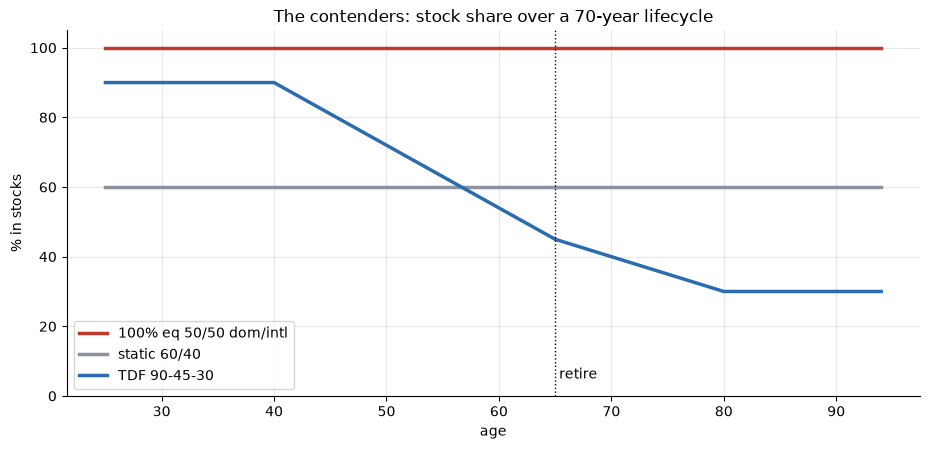

mechanics: save 1 unit/yr (real) ages 25-64, retire at 65, withdraw 4% of the pot (fixed real) to 95; ruin = broke before 95


In [2]:
age = 25 + np.arange(st.HORIZON)
fig, ax = plt.subplots(figsize=(9.4, 4.6))
for s, c in [('alleq', RED), ('s6040', GREY), ('tdf', BLUE)]:
    eq = st.weights_for(s).sum(axis=1)
    ax.plot(age, 100*eq, lw=2.5, color=c, label=LBL[s])
ax.axvline(65, ls=':', c='k', lw=1); ax.annotate(' retire', (65, 5))
ax.set_xlabel('age'); ax.set_ylabel('% in stocks'); ax.set_ylim(0, 105)
ax.legend(); ax.set_title('The contenders: stock share over a 70-year lifecycle')
plt.tight_layout(); plt.show()
print('mechanics: save 1 unit/yr (real) ages 25-64, retire at 65, withdraw 4% of'
      ' the pot (fixed real) to 95; ruin = broke before 95')

## 2 · So what?

Target-date funds hold **trillions** of default retirement savings. If the paper is right, the single most common retirement product in America is leaving enormous wealth — and *safety* — on the table. If it's only half right, the actionable half matters just as much: which half?

## 3 · How would we even know?

We run **every possible 70-year lifecycle** on the tape — 990 of them, one starting every month from 1871-02 to 1953-07 (retirements 1911-02 → 1993-07). Real (inflation-adjusted) returns for US stocks and 10-year Treasuries come from Shiller's data. **International stocks are the honest compromise**: real fund data (EFA) exists only from 2001-09 — 14% of the tape — so the earlier years are a *simulation calibrated to the century-long literature numbers* (4.3%/yr real, correlation 0.60 with the US). We say so on every chart, and we re-run everything with a pure-US variant (no simulation anywhere) and a worst-case correlation stress. Costs: 10 bps per trade + 5 bps/yr fund fees.

## 4 · The teardown — let's actually look

**The scoreboard first.** Wealth is in multiples of your annual savings contribution; *ruin* means the money ran out before age 95:

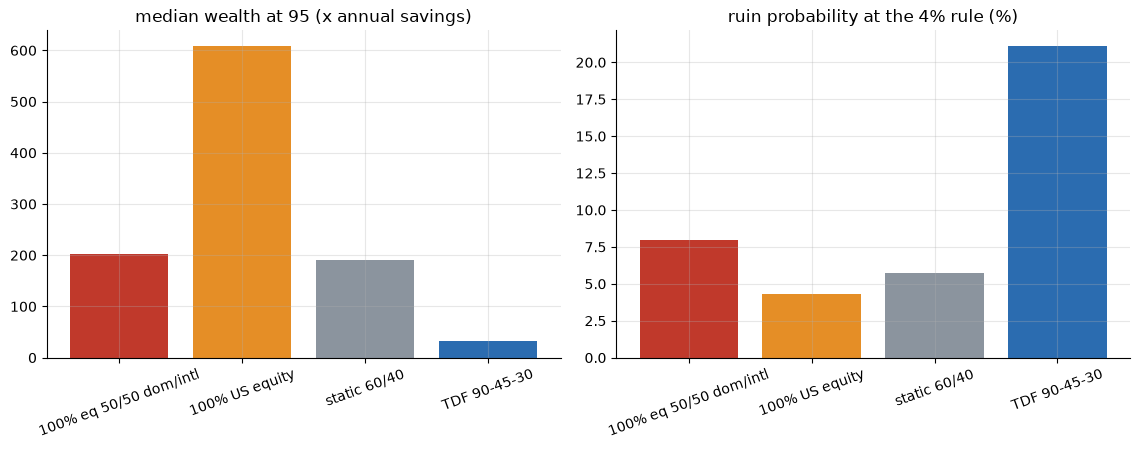

100% eq 50/50 dom/intl       pot@65 med  116.0  terminal med  203.3  ruin  7.98%
100% US equity               pot@65 med  169.4  terminal med  608.7  ruin  4.34%
static 60/40                 pot@65 med  125.4  terminal med  190.6  ruin  5.76%
TDF 90-45-30                 pot@65 med   97.5  terminal med   31.9  ruin 21.11%


In [3]:
if HAVE_REAL:
    res4 = st.run_all(GU, GI, GB, wr=0.04)
    score = {s: (float(np.median(res4[s]['wret'])), res4[s]['terminal'].mean(),
                 float(np.median(res4[s]['terminal'])),
                 float(np.quantile(res4[s]['terminal'], .05)),
                 100*(~res4[s]['success']).mean(), int((~res4[s]['success']).sum()))
             for s in STRATS}
else:
    res4, score = None, R['score']
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))
cols = {'alleq': RED, 'alleq_dom': '#e58e26', 's6040': GREY, 'tdf': BLUE}
names = [LBL[s] for s in STRATS]
axes[0].bar(names, [score[s][2] for s in STRATS], color=[cols[s] for s in STRATS])
axes[0].set_title('median wealth at 95 (x annual savings)')
axes[0].tick_params(axis='x', rotation=20)
axes[1].bar(names, [score[s][4] for s in STRATS], color=[cols[s] for s in STRATS])
axes[1].set_title('ruin probability at the 4% rule (%)')
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()
for s in STRATS:
    v = score[s]
    print(f'{LBL[s]:<28} pot@65 med {v[0]:6.1f}  terminal med {v[2]:6.1f}  ruin {v[4]:5.2f}%')

Three things jump out. **The TDF loses badly** — median wealth at 95 of **32×** vs **191×** for the 60/40 and **203×** for the paper's all-equity mix, and it dies broke in **21%** of cohorts (its bond-heavy retirement years met the 1940s–70s, when inflation ate bonds alive). **The paper's 50/50 mix does NOT beat the 60/40 where it counts** — median wealth is a tie (203 vs 191) and its ruin rate is *higher* (8.0% vs 5.8%). And **100% US stocks crushes everything** — which is exactly the bet the paper was trying *not* to make you take.

**Now the worst retirements in history.** Pot normalized to 1 at retirement (the 4% rule scales with your own pot):

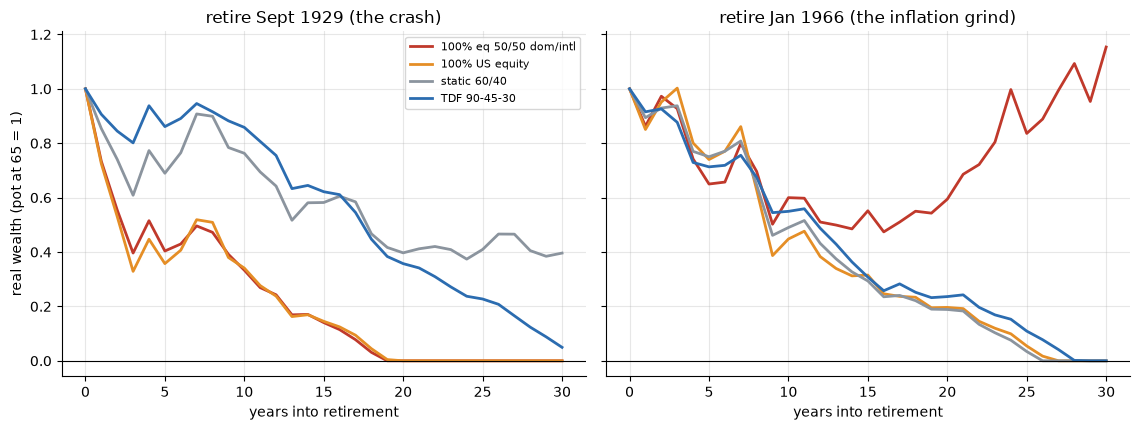

terminal @4% (x annual savings):
  1929-09 {'alleq': (0.0, 18), 'alleq_dom': (0.0, 18), 's6040': (62.0, -1), 'tdf': (3.8, -1), 'alleq_corr1': (0.0, 16)}
  1966-01 {'alleq': (190.9, -1), 'alleq_dom': (0.0, 25), 's6040': (0.0, 25), 'tdf': (0.0, 27), 'alleq_corr1': (0.0, 20)}


In [4]:
def ret_path(i, name, wr=0.04):
    # illustrative annual retirement path, ex-costs, pot normalized to 1 at 65
    w = st.weights_for(name)[st.SAVE_YEARS:]
    G = [GU[i, st.SAVE_YEARS:], GI[i, st.SAVE_YEARS:], GB[i, st.SAVE_YEARS:]]
    out = [1.0]; W = 1.0
    for j in range(st.RET_YEARS):
        if W <= wr: out += [0.0] * (st.RET_YEARS - j); break
        W -= wr
        W = (w[j, 0] * G[0][j] + w[j, 1] * G[1][j]
             + (1 - w[j, 0] - w[j, 1]) * G[2][j]) * W
        out.append(max(W, 0.0))
    return np.array(out[:st.RET_YEARS + 1])
if HAVE_REAL:
    import pandas as pd
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4), sharey=True)
    for ax, start, title in [(axes[0], '1889-09-01', 'retire Sept 1929 (the crash)'),
                             (axes[1], '1926-01-01', 'retire Jan 1966 (the inflation grind)')]:
        i = int(np.where(DATES == pd.Timestamp(start))[0][0])
        for name, c in [('alleq', RED), ('alleq_dom', '#e58e26'), ('s6040', GREY), ('tdf', BLUE)]:
            ax.plot(ret_path(i, name), c=c, lw=2, label=LBL[name])
        ax.axhline(0, c='k', lw=.8); ax.set_title(title)
        ax.set_xlabel('years into retirement')
    axes[0].set_ylabel('real wealth (pot at 65 = 1)'); axes[0].legend(fontsize=8)
    plt.tight_layout(); plt.show()
print('terminal @4% (x annual savings):')
for ym in ('1929-09', '1966-01'):
    print(' ', ym, {k: v for k, v in R['famous'][ym].items()})

**Left — 1929.** Every all-equity variant goes **broke around year 18**, while the 60/40 sails through (terminal 62× the annual contribution). Retiring 100%-in-stocks into the Great Depression is exactly the nightmare bonds exist for.

**Right — 1966.** Here *everything domestic* dies (stocks and bonds lost real value together for 15 years) — except the paper's mix, which survives with 191×… **because of its international half.** But careful: in 1966–1996 our international leg is the *simulated* one. Run the same cohort with the no-diversification stress and it goes broke in year 20. The strategy's best rescue story rests on the part of the data that isn't data.

> 🔬 For the quants: the wealth edge vs the TDF is certified at HAC *t* = +2.63 with a bootstrap CI excluding 0; the edge vs 60/40 is *t* = +1.22 — not certifiable. Details in [02_for_the_quants](02_for_the_quants.ipynb).

## 5 · The verdict

- **Signal — Mixed.** Against the **target-date fund**, the paper is right and it's real: more wealth (*t* ≈ +2.6), far less ruin. Against the plain **60/40**, the paper's own 50/50 domestic/international mix never certifies — median tie, and *more* ruin on this tape.
- **Tradability — Fragile.** Two index funds and ~5 bps of fees; costs don't move the answer at all. What's fragile is everything else: you need 70 years, the discipline to hold 100% stocks through a −80% real drawdown, and the safety half of the promise didn't replicate.
- **Worst cohorts — Busted.** 1929 ruins every all-equity variant while 60/40 survives; 1966 is survived only by the simulated international leg.

**In plain terms:** dumping the target-date glidepath for more equity is historically defensible. Dumping your *bonds* — the 60/40 — for a globally diversified all-stock portfolio bought you a coin-flip with a worse worst case.

## 6 · Going further 🚪

- **Why did the paper find the opposite?** Its 38-country panel contains bond returns far worse than the US 10-year (hyperinflations, wars) and international equity sampled from *winning* developed markets. Change the ingredients, change the dish — our tape anchors on the actual US bond experience and the century-long world-ex-US 4.3%/yr.
- **The US-only bet.** [Study 151 — stocks-for-long-run](../../151-stocks-for-long-run/README.md) grades the "US stocks always win given 30 years" claim that `alleq_dom` silently rides.
- **The glidepath autopsy.** [Study 596 — bond-tent-glidepath](../../596-bond-tent-glidepath/README.md) dissects *why* bond-heavy retirement years fail on this tape: the 1966–82 inflation grind, not the 1929 crash, is history's retirement killer.
- **The honest caveat, one more time.** 85.7% of our international leg is a literature-calibrated simulation (labeled everywhere, stress-tested both ways). A true 150-year global monthly tape (DMS is annual and proprietary) could move the blend's numbers — in *either* direction.

*The quants notebook re-runs the race under every international assumption, boots the tape 600 times, and rebuilds the paper's own 2,000-lifetime bootstrap.*